# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)


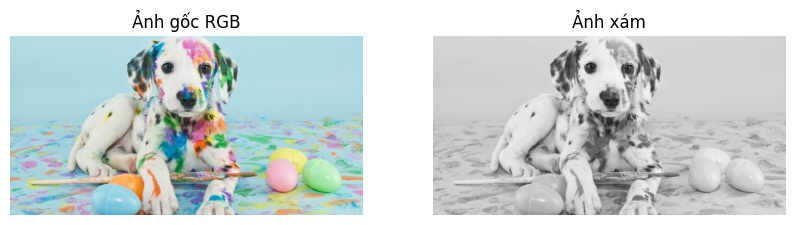

In [2]:
# Import thư viện và đọc ảnh
import cv2 as cv
import numpy as np
import matplotlib.pyplot as vuong

# Đọc ảnh dog.jpg
img = cv.imread('dog.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Hiển thị ảnh gốc
vuong.figure(figsize=(10,5))
vuong.subplot(1,2,1)
vuong.imshow(img_rgb)
vuong.title('Ảnh gốc RGB')
vuong.axis('off')

vuong.subplot(1,2,2)
vuong.imshow(img_gray, cmap='gray')
vuong.title('Ảnh xám')
vuong.axis('off')
vuong.show()

## 1. THRESHOLDING - Phân đoạn ảnh bằng Ngưỡng (Thresholding)

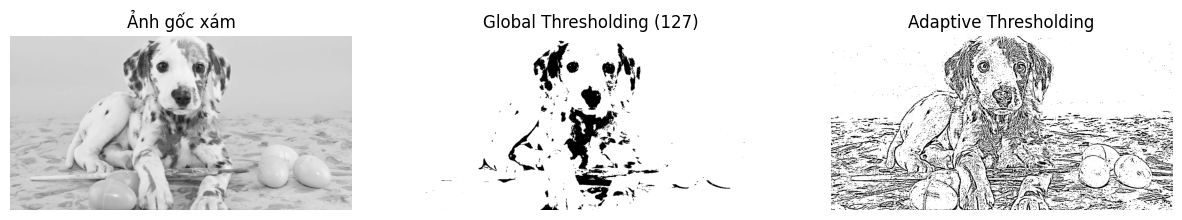

In [ ]:
# Sử dụng threshold đơn giản (global thresholding)
ret, thresh_binary = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

# Adaptive threshold - KHÔNG có giá trị trả về thứ nhất
thresh_adaptive = cv.adaptiveThreshold(img_gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

vuong.figure(figsize=(15,5))
vuong.subplot(1,3,1)
vuong.imshow(img_gray, cmap='gray')
vuong.title('Ảnh gốc xám')
vuong.axis('off')

vuong.subplot(1,3,2)
vuong.imshow(thresh_binary, cmap='gray')
vuong.title('Global Thresholding (127)')
vuong.axis('off')

vuong.subplot(1,3,3)
vuong.imshow(thresh_adaptive, cmap='gray')
vuong.title('Adaptive Thresholding')
vuong.axis('off')
vuong.show()

## 2. OTSU ALGORITHM - Phân đoạn ảnh vân tay bằng Otsu

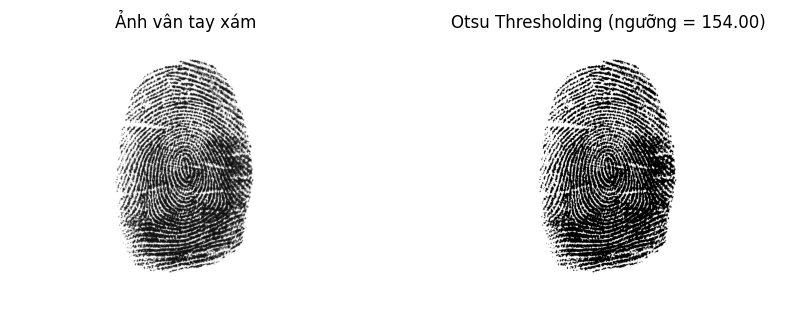

In [ ]:


# Đọc ảnh vân tay 
fingerprint_img = cv.imread('vantay.webp')
fingerprint_gray = cv.cvtColor(fingerprint_img, cv.COLOR_BGR2GRAY)

# Áp dụng Otsu thresholding
ret_otsu, thresh_otsu = cv.threshold(fingerprint_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

vuong.figure(figsize=(10,5))
vuong.subplot(1,2,1)
vuong.imshow(fingerprint_gray, cmap='gray')
vuong.title('Ảnh vân tay xám')
vuong.axis('off')

vuong.subplot(1,2,2)
vuong.imshow(thresh_otsu, cmap='gray')
vuong.title(f'Otsu Thresholding (ngưỡng = {ret_otsu:.2f})')
vuong.axis('off')
vuong.show()

## 3. K-MEANS CLUSTERING - Phân đoạn ảnh bằng K-means

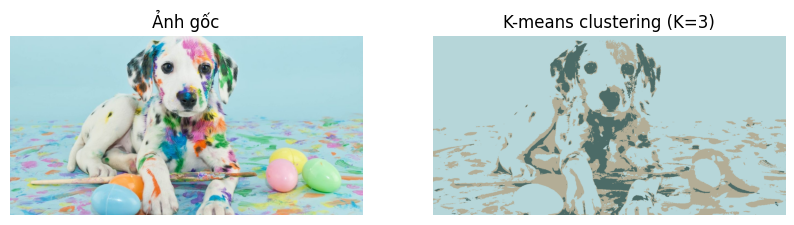

In [ ]:
# Chuẩn bị dữ liệu: reshape ảnh thành mảng các pixel
pixel_vals = img_rgb.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

# Áp dụng K-means với K=3 (3 cụm màu)
k = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
retval, labels, centers = cv.kmeans(pixel_vals, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

vuong.figure(figsize=(10,5))
vuong.subplot(1,2,1)
vuong.imshow(img_rgb)
vuong.title('Ảnh gốc')
vuong.axis('off')

vuong.subplot(1,2,2)
vuong.imshow(segmented_image)
vuong.title(f'K-means clustering (K={k})')
vuong.axis('off')
vuong.show()

## 4. REGION GROWING - Phân đoạn ảnh bằng Region Growing

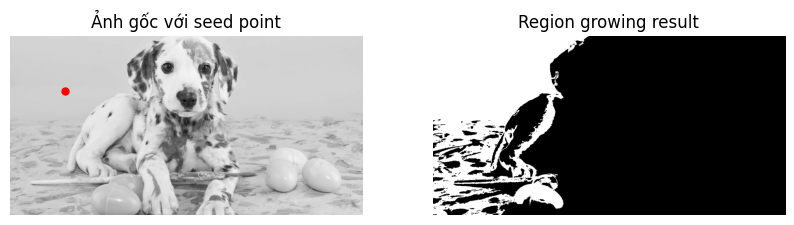

In [7]:
# Hàm region growing 
def region_growing(img, seed, threshold=10):
    # img: ảnh xám
    # seed: (x, y) tọa độ hạt giống
    h, w = img.shape
    segmented = np.zeros_like(img)
    visited = np.zeros_like(img, dtype=bool)
    
    seed_value = img[seed[1], seed[0]]
    queue = [seed]
    visited[seed[1], seed[0]] = True
    
    while queue:
        x, y = queue.pop(0)
        if abs(int(img[y, x]) - int(seed_value)) <= threshold:
            segmented[y, x] = 255
            # Duyệt 4 lân cận
            for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h and not visited[ny, nx]:
                    visited[ny, nx] = True
                    queue.append((nx, ny))
    return segmented

# Chọn seed point (có thể điều chỉnh tọa độ)
seed_point = (200, 200)  # ví dụ tọa độ (x, y)
region_result = region_growing(img_gray, seed_point, threshold=15)

vuong.figure(figsize=(10,5))
vuong.subplot(1,2,1)
vuong.imshow(img_gray, cmap='gray')
vuong.plot(seed_point[0], seed_point[1], 'ro', markersize=5)
vuong.title('Ảnh gốc với seed point')
vuong.axis('off')

vuong.subplot(1,2,2)
vuong.imshow(region_result, cmap='gray')
vuong.title('Region growing result')
vuong.axis('off')
vuong.show()

## 5. SPLIT AND MERGE - Phân đoạn ảnh bằng Split and Merge

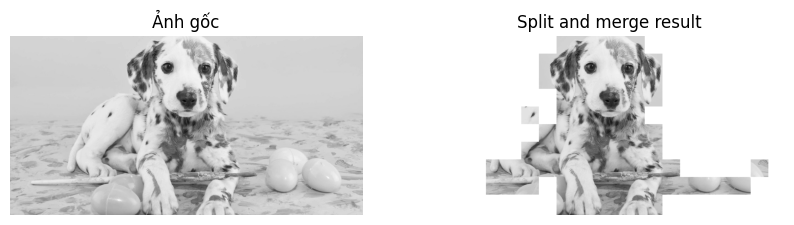

In [8]:

def split_merge(img, min_block_size=32, threshold=15):
    h, w = img.shape
    segmented = np.zeros_like(img)
    
    # Duyệt qua các block
    for y in range(0, h, min_block_size):
        for x in range(0, w, min_block_size):
            block = img[y:y+min_block_size, x:x+min_block_size]
            if block.size > 0:
                std_val = np.std(block)
                if std_val < threshold:
                    # Gộp: tô màu trắng
                    segmented[y:y+min_block_size, x:x+min_block_size] = 255
                else:
                    # Giữ nguyên block (hoặc để đen)
                    segmented[y:y+min_block_size, x:x+min_block_size] = block
    return segmented

split_merge_result = split_merge(img_gray, min_block_size=64, threshold=20)

vuong.figure(figsize=(10,5))
vuong.subplot(1,2,1)
vuong.imshow(img_gray, cmap='gray')
vuong.title('Ảnh gốc')
vuong.axis('off')

vuong.subplot(1,2,2)
vuong.imshow(split_merge_result, cmap='gray')
vuong.title('Split and merge result')
vuong.axis('off')
vuong.show()

## 6. EDGE-BASED SEGMENTATION - Phân đoạn ảnh dựa trên Cạnh (Edge)

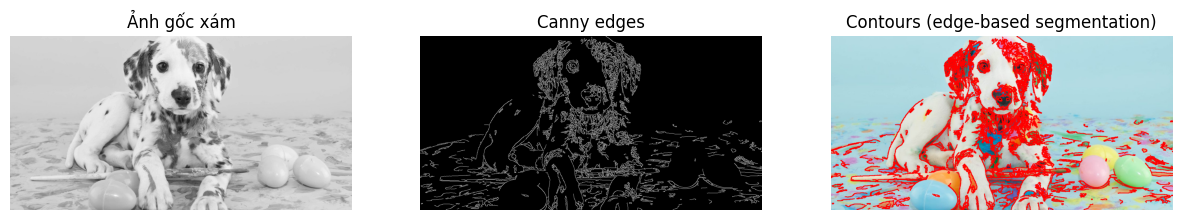

In [9]:
# Sử dụng Canny edge detector và tìm contour
edges = cv.Canny(img_gray, 50, 150)
contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Vẽ các contour lên ảnh gốc
img_contour = img_rgb.copy()
cv.drawContours(img_contour, contours, -1, (255, 0, 0), 2)

vuong.figure(figsize=(15,5))
vuong.subplot(1,3,1)
vuong.imshow(img_gray, cmap='gray')
vuong.title('Ảnh gốc xám')
vuong.axis('off')

vuong.subplot(1,3,2)
vuong.imshow(edges, cmap='gray')
vuong.title('Canny edges')
vuong.axis('off')

vuong.subplot(1,3,3)
vuong.imshow(img_contour)
vuong.title('Contours (edge-based segmentation)')
vuong.axis('off')
vuong.show()